# Spotify Listener Statistics — Exploratory Data Analysis

## Business Scenario

You are working as a Junior Data Scientist at Spotify. The business team wants to understand how users consume music across different countries, artists, genres, albums, release years, and subscription types.

## Business Objectives

This analysis aims to identify:

- Most popular countries and regions
- Most streamed artists
- Most popular genres
- Listener engagement patterns
- Free vs Premium listening behavior
- High-performing albums
- Recent streaming trends
- Skip-rate patterns
- Artists with strong listener engagement
- Genres with strong future promotion potential
- Release-year streaming patterns

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

No machine learning is used in this project.

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Consistent plotting settings
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Spotify Dataset

The dataset is loaded from the local Spotify project directory.

A file-existence check is included so the notebook fails with a clear message instead of producing a confusing downstream error.

In [2]:
# ============================================================
# 2. LOAD DATA
# ============================================================

# Prefer the dataset stored beside the notebook so the project is portable.
file_path = Path("Spotify_2024_Global_Streaming_Data.csv")

# Retain the original local location as a fallback for existing users.
if not file_path.exists():
    original_file_path = Path(r"D:\Spotify\Spotify_2024_Global_Streaming_Data.csv")
    if original_file_path.exists():
        file_path = original_file_path
    else:
        raise FileNotFoundError(
            "Spotify dataset was not found beside the notebook or at:\n"
            f"{original_file_path}"
        )

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Source: {file_path.resolve()}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")


Dataset loaded successfully.
Source: C:\Users\Alok Agarwal\Documents\Codex\2026-09-04\referenced-chatgpt-conversation-this-is-an-3\work\spotify-listener-statistics-eda\Spotify_2024_Global_Streaming_Data.csv
Rows: 500
Columns: 12


## 3. Validate Required Columns

Before analysis, the notebook checks whether all columns required for the business questions are present.

In [3]:
# ============================================================
# 3. VALIDATE REQUIRED COLUMNS
# ============================================================

# Remove accidental spaces around column names
df.columns = df.columns.str.strip()

required_columns = [
    "Country",
    "Artist",
    "Album",
    "Genre",
    "Release Year",
    "Monthly Listeners (Millions)",
    "Total Streams (Millions)",
    "Total Hours Streamed (Millions)",
    "Avg Stream Duration (Min)",
    "Platform Type",
    "Streams Last 30 Days (Millions)",
    "Skip Rate (%)",
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "The following required columns are missing:\n"
        + "\n".join(f"- {column}" for column in missing_columns)
    )

print("All required columns are available.")

All required columns are available.


## 4. Data Understanding

This section examines:

- Dataset dimensions
- Column names
- Data types
- Sample records
- Descriptive statistics

In [4]:
# ============================================================
# 4. DATA UNDERSTANDING
# ============================================================

print("Dataset shape:", df.shape)

print("\nColumn names:")
for number, column in enumerate(df.columns, start=1):
    print(f"{number}. {column}")

print("\nDataset information:")
df.info()

print("\nFirst 5 rows:")
display(df.head())

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Dataset shape: (500, 12)

Column names:
1. Country
2. Artist
3. Album
4. Genre
5. Release Year
6. Monthly Listeners (Millions)
7. Total Streams (Millions)
8. Total Hours Streamed (Millions)
9. Avg Stream Duration (Min)
10. Platform Type
11. Streams Last 30 Days (Millions)
12. Skip Rate (%)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          500 non-null    str    
 1   Artist                           500 non-null    str    
 2   Album                            500 non-null    str    
 3   Genre                            500 non-null    str    
 4   Release Year                     500 non-null    int64  
 5   Monthly Listeners (Millions)     500 non-null    float64
 6   Total Streams (Millions)         500 non-null    float64
 7   Total Hours Streamed (Millions

,Country,Artist,Album,Genre,Release Year,Monthly Listeners (Millions),Total Streams (Millions),Total Hours Streamed (Millions),Avg Stream Duration (Min),Platform Type,Streams Last 30 Days (Millions),Skip Rate (%)
0,Germany,Taylor Swift,1989 (Taylor's Version),K-pop,2019,23.10,"3,695.53","14,240.35",4.28,Free,118.51,2.24
1,Brazil,The Weeknd,After Hours,R&B,2022,60.60,"2,828.16","11,120.44",3.90,Premium,44.87,23.98
2,United States,Post Malone,Austin,Reggaeton,2023,42.84,"1,425.46","4,177.49",4.03,Free,19.46,4.77
3,Italy,Ed Sheeran,Autumn Variations,K-pop,2018,73.24,"2,704.33","12,024.08",3.26,Premium,166.05,25.12
4,Italy,Ed Sheeran,Autumn Variations,R&B,2023,7.89,"3,323.25","13,446.32",4.47,Free,173.43,15.82



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,500,20,Italy,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Artist,500,15,BTS,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Album,500,15,Proof,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genre,500,10,Classical,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Release Year,500.00,NaN,NaN,NaN,"2,020.49",1.67,"2,018.00","2,019.00","2,020.00","2,022.00","2,023.00"
Monthly Listeners (Millions),500.00,NaN,NaN,NaN,51.04,28.24,1.01,27.67,50.83,75.09,99.80
Total Streams (Millions),500.00,NaN,NaN,NaN,"2,581.15","1,416.06",53.56,"1,337.34","2,697.35","3,798.20","4,985.54"
Total Hours Streamed (Millions),500.00,NaN,NaN,NaN,"8,954.37","5,167.65",184.30,"4,322.10","9,053.67","12,690.18","21,874.92"
Avg Stream Duration (Min),500.00,NaN,NaN,NaN,3.52,0.57,2.51,3.03,3.54,4.00,4.49
Platform Type,500,2,Free,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Data Quality Assessment

The dataset is checked for:

- Missing values
- Duplicate rows
- Blank category values
- Invalid numeric values
- Negative values
- Invalid skip rates
- Unrealistic release years

In [5]:
# ============================================================
# 5. DATA QUALITY CHECKS
# ============================================================

print("Missing values by column:")
missing_summary = df.isna().sum().sort_values(ascending=False)
display(missing_summary.to_frame("Missing Values"))

duplicate_count = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicate_count:,}")

categorical_columns = [
    "Country",
    "Artist",
    "Album",
    "Genre",
    "Platform Type",
]

print("\nBlank-string checks:")
for column in categorical_columns:
    blank_count = (
        df[column]
        .astype("string")
        .str.strip()
        .eq("")
        .sum()
    )
    print(f"{column}: {blank_count:,}")

print("\nCategorical consistency checks:")
for column in ["Country", "Genre", "Platform Type"]:
    standardized_values = (
        df[column]
        .astype("string")
        .str.strip()
        .str.casefold()
    )
    inconsistent_labels = (
        pd.DataFrame({"original": df[column], "standardized": standardized_values})
        .drop_duplicates()
        .groupby("standardized")["original"]
        .nunique()
    )
    inconsistent_count = int((inconsistent_labels > 1).sum())
    print(f"{column}: {inconsistent_count} inconsistent label group(s)")

numeric_quality_columns = [
    "Monthly Listeners (Millions)",
    "Total Streams (Millions)",
    "Total Hours Streamed (Millions)",
    "Avg Stream Duration (Min)",
    "Streams Last 30 Days (Millions)",
    "Skip Rate (%)",
]

# Flag potential outliers with the IQR rule. They are retained because high
# streaming values can represent genuine top-performing artists or markets.
outlier_rows = []
for column in numeric_quality_columns:
    values = pd.to_numeric(df[column], errors="coerce").dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    count = int(((values < lower_bound) | (values > upper_bound)).sum())
    outlier_rows.append(
        {
            "Column": column,
            "Potential Outliers": count,
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
        }
    )

print("\nPotential outliers (IQR method):")
display(pd.DataFrame(outlier_rows))


Missing values by column:


,Missing Values
Country,0
Artist,0
Album,0
Genre,0
Release Year,0
Monthly Listeners (Millions),0
Total Streams (Millions),0
Total Hours Streamed (Millions),0
Avg Stream Duration (Min),0
Platform Type,0



Duplicate rows: 0

Blank-string checks:
Country: 0
Artist: 0
Album: 0
Genre: 0
Platform Type: 0

Categorical consistency checks:
Country: 0 inconsistent label group(s)
Genre: 0 inconsistent label group(s)
Platform Type: 0 inconsistent label group(s)

Potential outliers (IQR method):


,Column,Potential Outliers,Lower Bound,Upper Bound
0,Monthly Listeners (Millions),0,-43.46,146.23
1,Total Streams (Millions),0,"-2,353.95","7,489.49"
2,Total Hours Streamed (Millions),0,"-8,230.03","25,242.30"
3,Avg Stream Duration (Min),0,1.57,5.46
4,Streams Last 30 Days (Millions),0,-102.47,298.94
5,Skip Rate (%),0,-15.26,55.17


## 6. Data Cleaning

Cleaning includes:

- Removing duplicate records
- Standardizing text columns
- Converting analysis columns to numeric data types
- Converting invalid numeric values to missing values
- Removing clearly invalid records
- Preserving valid observations for analysis

In [6]:
# ============================================================
# 6. DATA CLEANING
# ============================================================

# Work on a copy so the originally loaded DataFrame remains available
clean_df = df.copy()

initial_rows = len(clean_df)

# ------------------------------------------------------------
# Remove duplicate records
# ------------------------------------------------------------

clean_df = clean_df.drop_duplicates().copy()

# ------------------------------------------------------------
# Standardize text fields
# ------------------------------------------------------------

for column in categorical_columns:
    clean_df[column] = (
        clean_df[column]
        .astype("string")
        .str.strip()
    )

# Convert blank strings to missing values
clean_df[categorical_columns] = clean_df[categorical_columns].replace(
    r"^\s*$",
    np.nan,
    regex=True
)

# ------------------------------------------------------------
# Convert numerical columns safely
# ------------------------------------------------------------

numeric_columns = [
    "Release Year",
    "Monthly Listeners (Millions)",
    "Total Streams (Millions)",
    "Total Hours Streamed (Millions)",
    "Avg Stream Duration (Min)",
    "Streams Last 30 Days (Millions)",
    "Skip Rate (%)",
]

for column in numeric_columns:
    clean_df[column] = pd.to_numeric(
        clean_df[column],
        errors="coerce"
    )

# ------------------------------------------------------------
# Validate impossible negative values
# ------------------------------------------------------------

non_negative_columns = [
    "Monthly Listeners (Millions)",
    "Total Streams (Millions)",
    "Total Hours Streamed (Millions)",
    "Avg Stream Duration (Min)",
    "Streams Last 30 Days (Millions)",
]

for column in non_negative_columns:
    clean_df.loc[clean_df[column] < 0, column] = np.nan

# Skip rate should be between 0 and 100
clean_df.loc[
    ~clean_df["Skip Rate (%)"].between(0, 100),
    "Skip Rate (%)"
] = np.nan

# Basic release-year validation
clean_df.loc[
    ~clean_df["Release Year"].between(1900, 2030),
    "Release Year"
] = np.nan

# Use nullable integer for release year
clean_df["Release Year"] = (
    clean_df["Release Year"]
    .round()
    .astype("Int64")
)

# ------------------------------------------------------------
# Remove rows missing essential identifiers
# ------------------------------------------------------------

essential_categories = [
    "Country",
    "Artist",
    "Album",
    "Genre",
    "Platform Type",
]

clean_df = clean_df.dropna(
    subset=essential_categories
).copy()

removed_rows = initial_rows - len(clean_df)

print("Cleaning completed successfully.")
print(f"Original rows: {initial_rows:,}")
print(f"Clean rows: {len(clean_df):,}")
print(f"Rows removed during cleaning: {removed_rows:,}")

Cleaning completed successfully.
Original rows: 500
Clean rows: 500
Rows removed during cleaning: 0


In [7]:
# ============================================================
# POST-CLEANING VALIDATION
# ============================================================

print("Remaining duplicate rows:", clean_df.duplicated().sum())

print("\nRemaining missing values:")
display(
    clean_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing Values")
)

print("\nPlatform values:")
print(clean_df["Platform Type"].value_counts(dropna=False))

print("\nGenre values:")
print(clean_df["Genre"].value_counts(dropna=False))

Remaining duplicate rows: 0

Remaining missing values:


,Missing Values
Country,0
Artist,0
Album,0
Genre,0
Release Year,0
Monthly Listeners (Millions),0
Total Streams (Millions),0
Total Hours Streamed (Millions),0
Avg Stream Duration (Min),0
Platform Type,0



Platform values:
Platform Type
Free       250
Premium    250
Name: count, dtype: int64[pyarrow]

Genre values:
Genre
Classical    72
Rock         58
EDM          51
Indie        50
Hip Hop      49
K-pop        48
Reggaeton    44
Pop          44
Jazz         43
R&B          41
Name: count, dtype: int64[pyarrow]


## 7. Export the Cleaned Dataset

The cleaned version is exported separately.

The original source CSV is not overwritten.

In [8]:
# ============================================================
# 7. EXPORT CLEANED DATASET
# ============================================================

cleaned_file_path = file_path.parent / "Spotify_2024_Cleaned_Data.csv"

clean_df.to_csv(
    cleaned_file_path,
    index=False
)

print("Cleaned dataset exported successfully:")
print(cleaned_file_path)

Cleaned dataset exported successfully:
Spotify_2024_Cleaned_Data.csv


# 8. Univariate Analysis

Univariate analysis examines individual variables to understand their distributions and dominant categories.

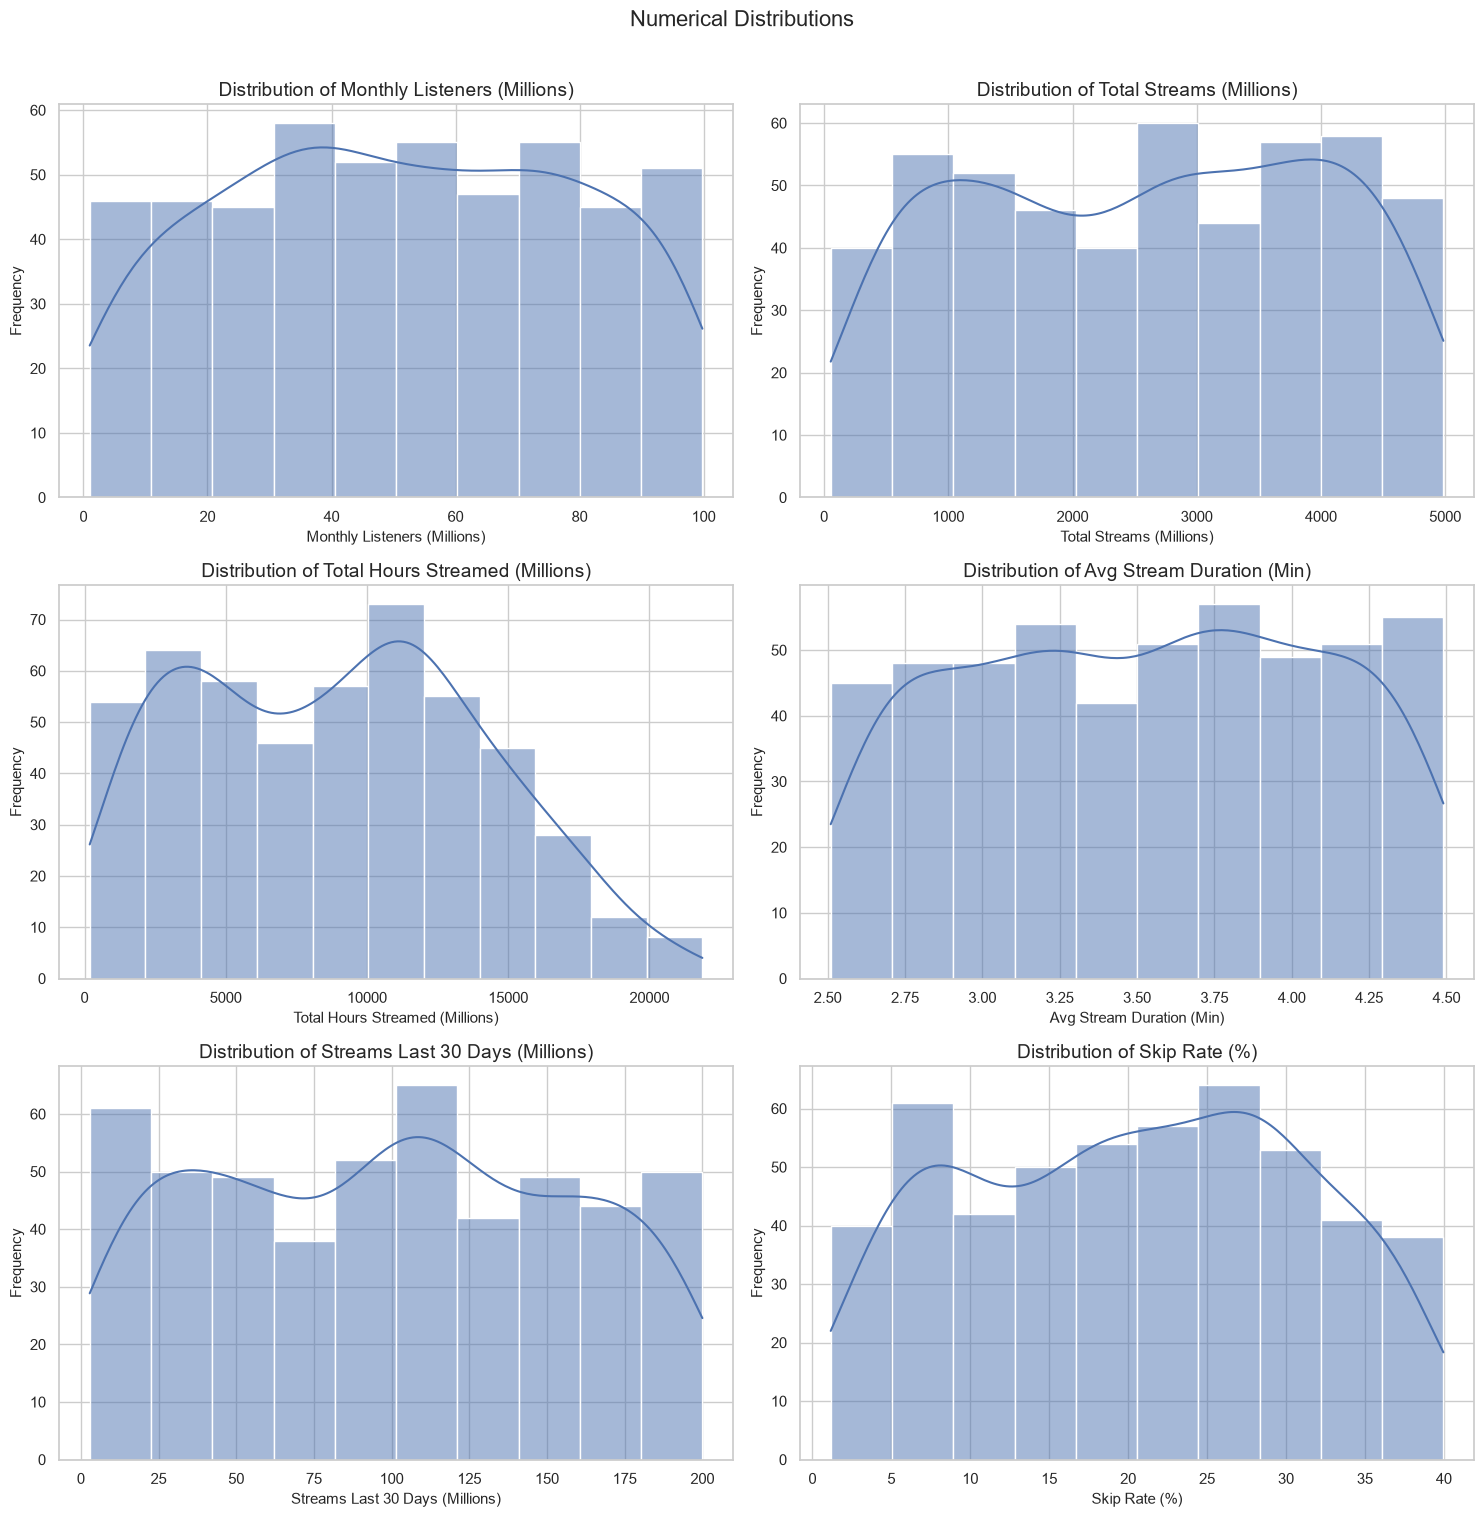

In [9]:
# ============================================================
# 8.1 NUMERICAL DISTRIBUTIONS
# ============================================================

numerical_analysis_columns = [
    "Monthly Listeners (Millions)",
    "Total Streams (Millions)",
    "Total Hours Streamed (Millions)",
    "Avg Stream Duration (Min)",
    "Streams Last 30 Days (Millions)",
    "Skip Rate (%)",
]

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
for column, axis in zip(numerical_analysis_columns, axes.flat):
    data = clean_df[column].dropna()
    if data.empty:
        axis.set_visible(False)
        continue
    sns.histplot(data=data, kde=True, ax=axis)
    axis.set_title(f"Distribution of {column}")
    axis.set_xlabel(column)
    axis.set_ylabel("Frequency")

fig.suptitle("Numerical Distributions", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


,Number of Records
Genre,
Classical,72
Rock,58
EDM,51
Indie,50
Hip Hop,49
K-pop,48
Reggaeton,44
Pop,44
Jazz,43


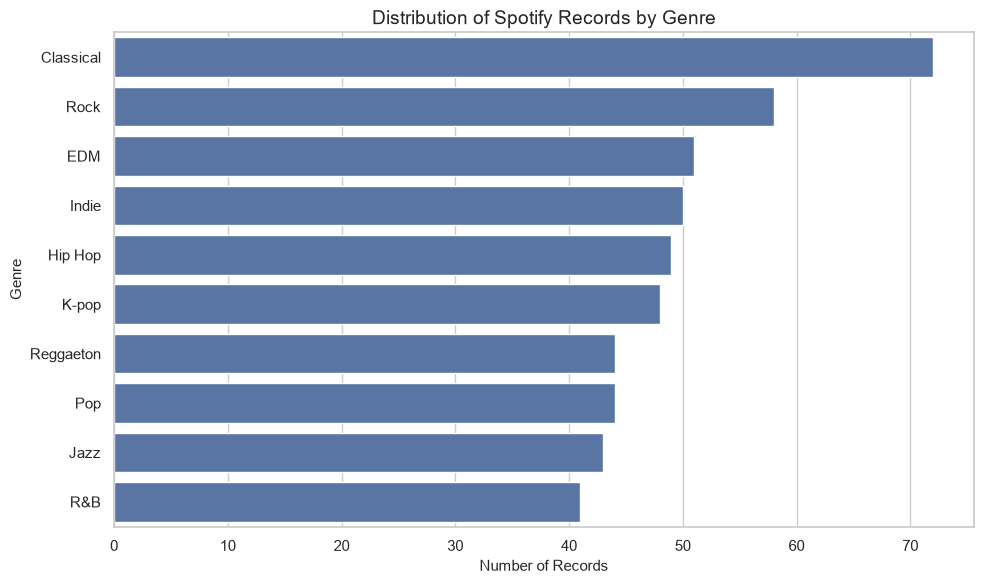

In [10]:
# ============================================================
# 8.2 GENRE DISTRIBUTION
# ============================================================

genre_counts = clean_df["Genre"].value_counts()

display(genre_counts.to_frame("Number of Records"))

plt.figure(figsize=(10, 6))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

plt.title("Distribution of Spotify Records by Genre")
plt.xlabel("Number of Records")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

,Number of Records
Platform Type,
Free,250
Premium,250


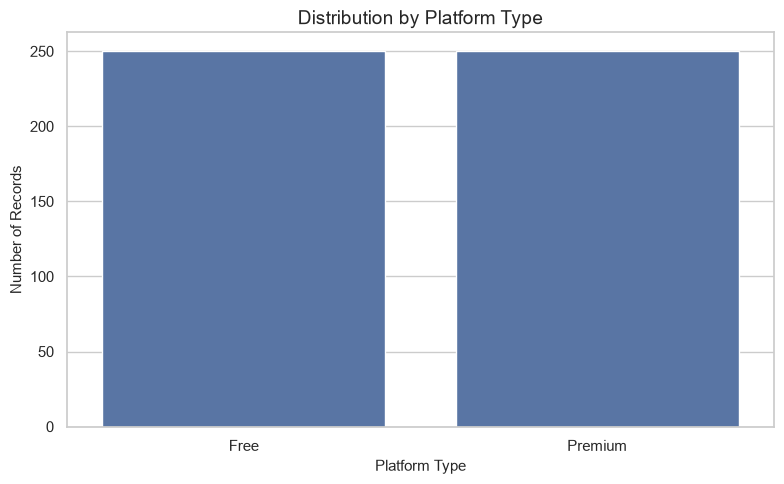

In [11]:
# ============================================================
# 8.3 PLATFORM DISTRIBUTION
# ============================================================

platform_counts = clean_df["Platform Type"].value_counts()

display(platform_counts.to_frame("Number of Records"))

plt.figure(figsize=(8, 5))

sns.barplot(
    x=platform_counts.index,
    y=platform_counts.values
)

plt.title("Distribution by Platform Type")
plt.xlabel("Platform Type")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

,Number of Records
Country,
Italy,34
South Africa,32
South Korea,31
Russia,31
Brazil,30
Sweden,30
Argentina,27
Canada,25
Spain,25


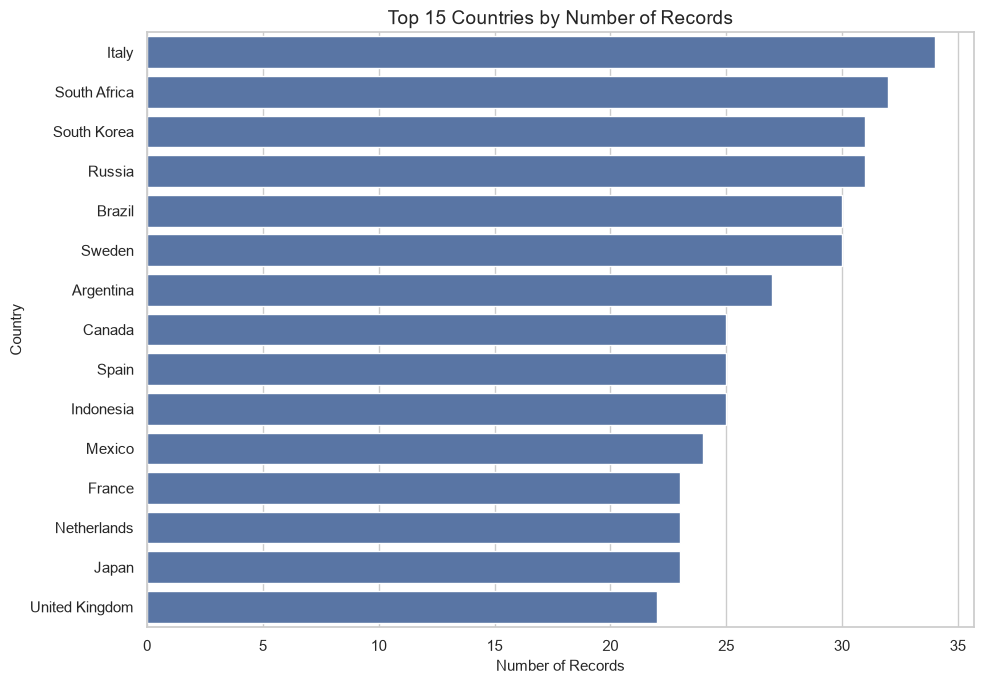

In [12]:
# ============================================================
# 8.4 COUNTRY DISTRIBUTION
# ============================================================

country_counts = clean_df["Country"].value_counts().head(15)

display(country_counts.to_frame("Number of Records"))

plt.figure(figsize=(10, 7))
sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)
plt.title("Top 15 Countries by Number of Records")
plt.xlabel("Number of Records")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


# 9. Bivariate Analysis

This section examines relationships between major listening and engagement variables.

In [13]:
# ============================================================
# 9.1 CORRELATION MATRIX
# ============================================================

correlation_columns = [
    "Monthly Listeners (Millions)",
    "Total Streams (Millions)",
    "Total Hours Streamed (Millions)",
    "Avg Stream Duration (Min)",
    "Streams Last 30 Days (Millions)",
    "Skip Rate (%)",
]

correlation_matrix = clean_df[correlation_columns].corr()
display(correlation_matrix)


,Monthly Listeners (Millions),Total Streams (Millions),Total Hours Streamed (Millions),Avg Stream Duration (Min),Streams Last 30 Days (Millions),Skip Rate (%)
Monthly Listeners (Millions),1.00,0.02,0.02,0.04,0.05,0.01
Total Streams (Millions),0.02,1.00,0.94,-0.01,0.05,-0.04
Total Hours Streamed (Millions),0.02,0.94,1.00,-0.02,0.05,-0.03
Avg Stream Duration (Min),0.04,-0.01,-0.02,1.00,0.12,-0.02
Streams Last 30 Days (Millions),0.05,0.05,0.05,0.12,1.00,0.03
Skip Rate (%),0.01,-0.04,-0.03,-0.02,0.03,1.00


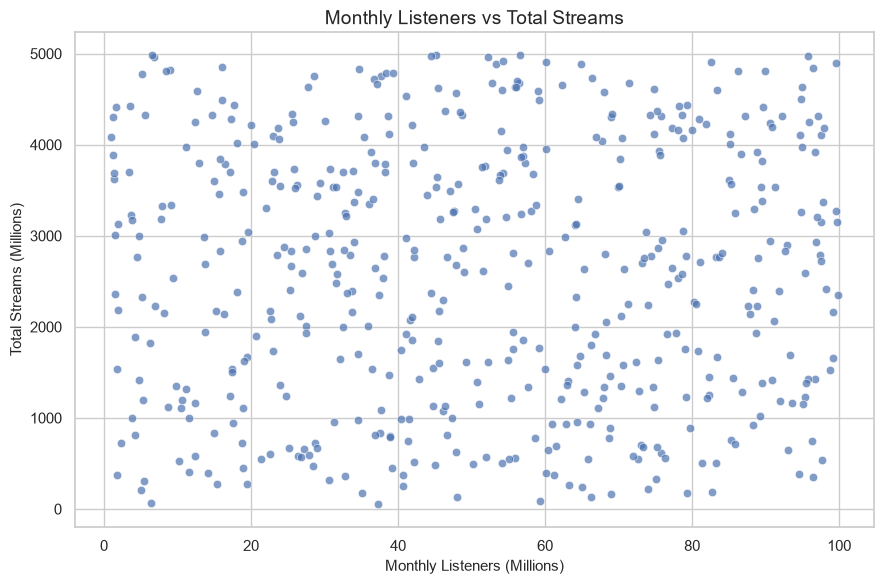

In [14]:
# ============================================================
# 9.2 MONTHLY LISTENERS VS TOTAL STREAMS
# ============================================================

plot_df = clean_df[
    [
        "Monthly Listeners (Millions)",
        "Total Streams (Millions)"
    ]
].dropna()

if not plot_df.empty:
    
    plt.figure(figsize=(9, 6))

    sns.scatterplot(
        data=plot_df,
        x="Monthly Listeners (Millions)",
        y="Total Streams (Millions)",
        alpha=0.7
    )

    plt.title("Monthly Listeners vs Total Streams")
    plt.xlabel("Monthly Listeners (Millions)")
    plt.ylabel("Total Streams (Millions)")

    plt.tight_layout()
    plt.show()

# 10. Regional Analysis

Regional performance is evaluated using:

- Total streams
- Monthly listener reach
- Streaming hours
- Recent streams
- Skip rate

In [15]:
# ============================================================
# 10. REGIONAL ANALYSIS
# ============================================================

country_summary = (
    clean_df
    .groupby("Country", as_index=False)
    .agg(
        Monthly_Listeners_M=("Monthly Listeners (Millions)", "sum"),
        Total_Streams_M=("Total Streams (Millions)", "sum"),
        Total_Hours_M=("Total Hours Streamed (Millions)", "sum"),
        Recent_Streams_M=("Streams Last 30 Days (Millions)", "sum"),
        Avg_Duration_Min=("Avg Stream Duration (Min)", "mean"),
        Avg_Skip_Rate=("Skip Rate (%)", "mean"),
    )
)

# Hours per monthly-listener unit provides a comparable regional engagement
# measure while using aggregated totals rather than row-level averages.
country_summary["Engagement_Score"] = np.where(
    country_summary["Monthly_Listeners_M"] > 0,
    country_summary["Total_Hours_M"] / country_summary["Monthly_Listeners_M"],
    np.nan,
)

country_summary = country_summary.sort_values(
    "Total_Streams_M",
    ascending=False
)

display(country_summary.head(10))


,Country,Monthly_Listeners_M,Total_Streams_M,Total_Hours_M,Recent_Streams_M,Avg_Duration_Min,Avg_Skip_Rate,Engagement_Score
16,Sweden,"1,522.51","93,449.76","315,891.87","3,023.20",3.63,21.79,207.48
14,South Korea,"1,326.65","87,594.21","315,992.38","3,171.34",3.47,20.97,238.19
13,South Africa,"1,555.70","87,431.73","296,353.83","3,024.99",3.48,22.07,190.50
2,Brazil,"1,566.40","77,383.15","262,069.82","3,063.11",3.76,20.59,167.31
8,Italy,"1,357.71","75,671.88","255,918.55","3,227.25",3.58,22.37,188.49
12,Russia,"1,603.45","69,990.43","261,481.56","2,886.25",3.45,21.90,163.07
10,Mexico,"1,264.39","67,240.71","249,586.91","2,421.30",3.27,19.62,197.40
4,France,940.59,"66,305.82","245,512.09","2,462.71",3.30,19.08,261.02
0,Argentina,"1,480.90","65,821.91","214,954.70","2,834.22",3.60,22.62,145.15
11,Netherlands,"1,330.47","61,741.17","220,382.79","2,295.39",3.47,17.66,165.64


,Country,Genre,Total_Streams_M
155,Sweden,Indie,"23,532.53"
22,Brazil,Pop,"20,902.78"
142,Spain,Classical,"20,008.05"
130,South Africa,Reggaeton,"19,347.27"
5,Argentina,K-pop,"17,284.01"
132,South Korea,Classical,"16,732.16"
112,Russia,Classical,"16,578.04"
26,Canada,Classical,"13,966.70"
74,Italy,Classical,"13,611.96"
168,Turkey,Rock,"12,770.44"


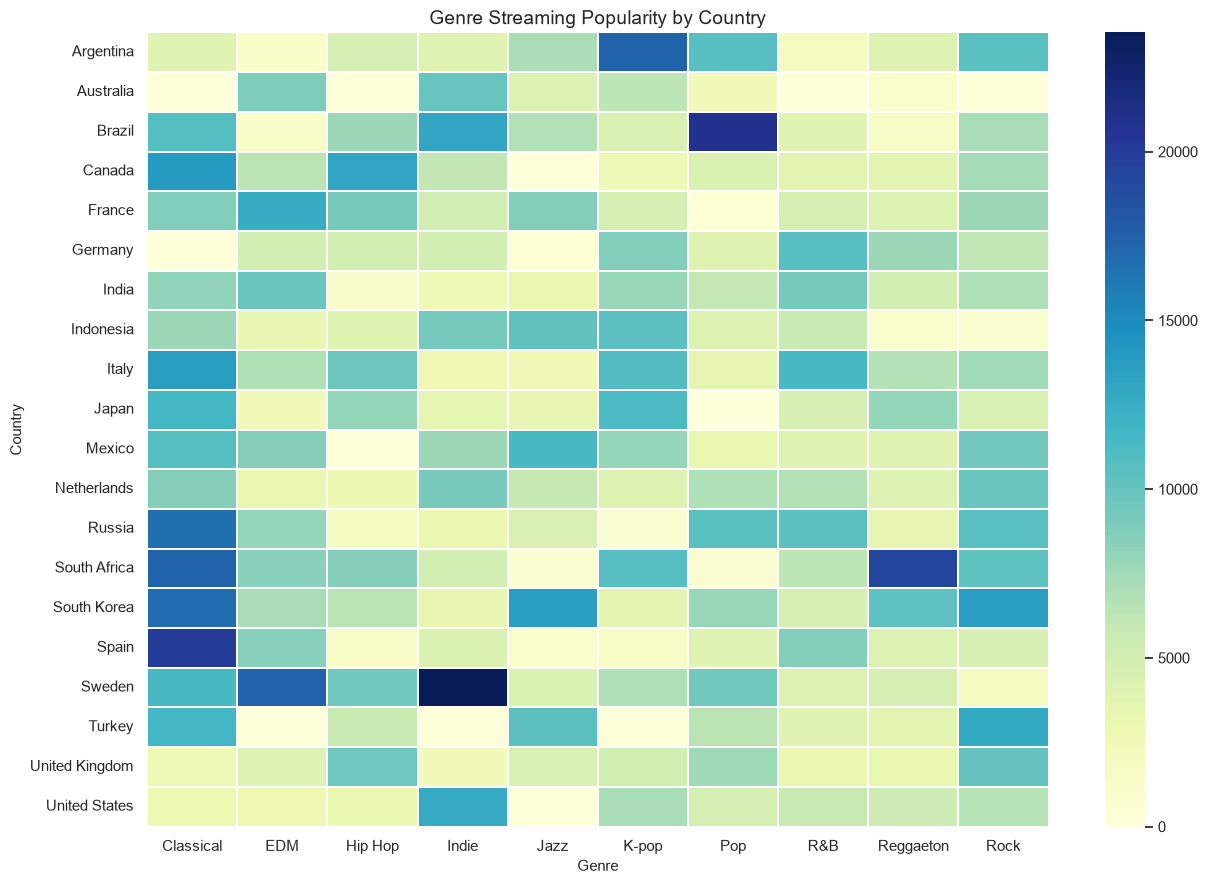

In [16]:
# ============================================================
# POPULAR GENRES BY REGION
# ============================================================

country_genre_streams = (
    clean_df
    .groupby(["Country", "Genre"], as_index=False)
    .agg(Total_Streams_M=("Total Streams (Millions)", "sum"))
)

top_genre_by_country = (
    country_genre_streams
    .sort_values(
        ["Country", "Total_Streams_M"],
        ascending=[True, False]
    )
    .drop_duplicates("Country")
    .sort_values("Total_Streams_M", ascending=False)
)

display(top_genre_by_country)

regional_genre_matrix = country_genre_streams.pivot(
    index="Country",
    columns="Genre",
    values="Total_Streams_M"
).fillna(0)

plt.figure(figsize=(13, 9))
sns.heatmap(
    regional_genre_matrix,
    cmap="YlGnBu",
    linewidths=0.25
)
plt.title("Genre Streaming Popularity by Country")
plt.xlabel("Genre")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


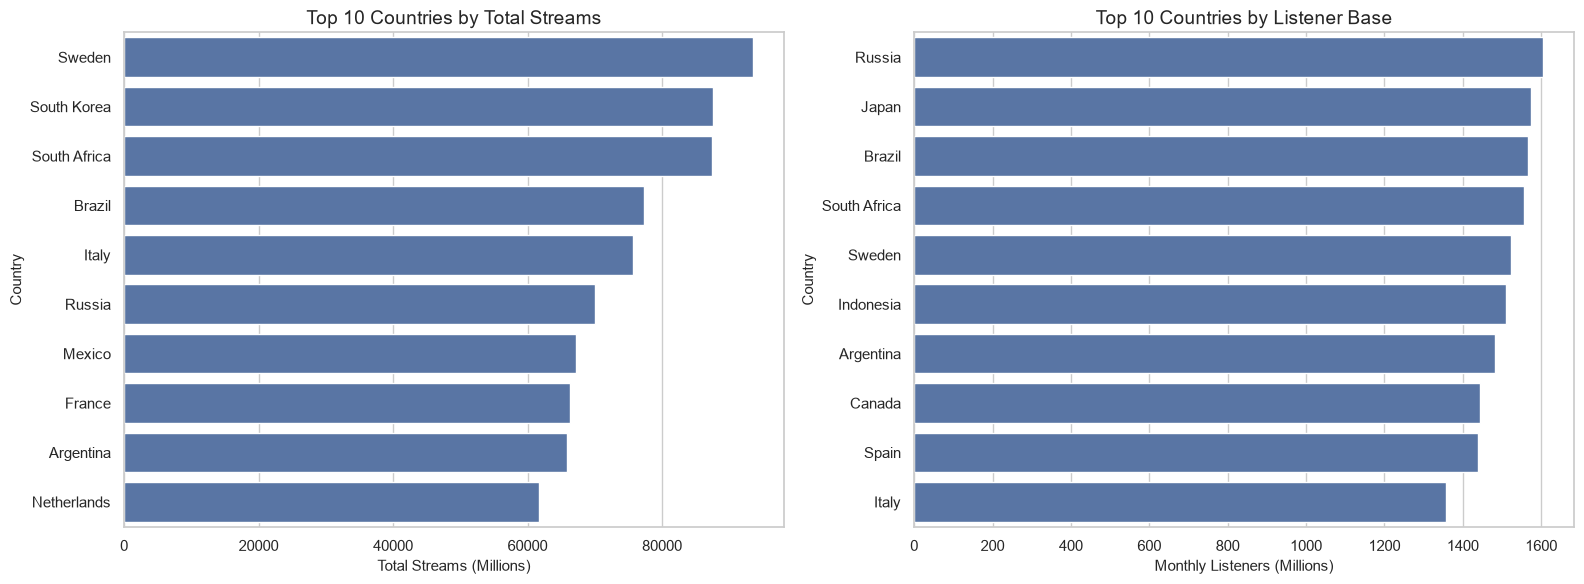

BUSINESS ANSWER — REGIONAL PERFORMANCE:
- Highest total streaming volume: Sweden (93,449.76M streams).
- Largest listener base: Russia (1,603.45M listeners).
- Strongest listener engagement: France (score 261.02).


In [17]:
# ============================================================
# TOP COUNTRIES BY STREAMS, LISTENERS, AND ENGAGEMENT
# ============================================================

top_stream_countries = country_summary.nlargest(10, "Total_Streams_M")
top_listener_countries = country_summary.nlargest(10, "Monthly_Listeners_M")
top_engagement_countries = country_summary.nlargest(10, "Engagement_Score")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top_stream_countries,
    x="Total_Streams_M",
    y="Country",
    ax=axes[0]
)
axes[0].set_title("Top 10 Countries by Total Streams")
axes[0].set_xlabel("Total Streams (Millions)")
axes[0].set_ylabel("Country")

sns.barplot(
    data=top_listener_countries,
    x="Monthly_Listeners_M",
    y="Country",
    ax=axes[1]
)
axes[1].set_title("Top 10 Countries by Listener Base")
axes[1].set_xlabel("Monthly Listeners (Millions)")
axes[1].set_ylabel("Country")

plt.tight_layout()
plt.show()

if country_summary.empty:
    print("Business Answer: No valid country data available.")
else:
    top_country = top_stream_countries.iloc[0]
    listener_country = top_listener_countries.iloc[0]
    engagement_country = top_engagement_countries.iloc[0]

    print(
        "BUSINESS ANSWER — REGIONAL PERFORMANCE:\n"
        f"- Highest total streaming volume: {top_country['Country']} "
        f"({top_country['Total_Streams_M']:,.2f}M streams).\n"
        f"- Largest listener base: {listener_country['Country']} "
        f"({listener_country['Monthly_Listeners_M']:,.2f}M listeners).\n"
        f"- Strongest listener engagement: {engagement_country['Country']} "
        f"(score {engagement_country['Engagement_Score']:.2f})."
    )


# 11. Artist Analysis

Artist performance is evaluated using aggregated listener reach, streams, streaming hours, recent streams, and skip behavior.

Artist engagement is calculated from aggregated totals rather than averaging row-level ratios.

In [18]:
# ============================================================
# 11. ARTIST PERFORMANCE
# ============================================================

artist_summary = (
    clean_df
    .groupby("Artist", as_index=False)
    .agg(
        Monthly_Listeners_M=(
            "Monthly Listeners (Millions)",
            "sum"
        ),
        Total_Streams_M=(
            "Total Streams (Millions)",
            "sum"
        ),
        Total_Hours_M=(
            "Total Hours Streamed (Millions)",
            "sum"
        ),
        Recent_Streams_M=(
            "Streams Last 30 Days (Millions)",
            "sum"
        ),
        Avg_Duration_Min=(
            "Avg Stream Duration (Min)",
            "mean"
        ),
        Avg_Skip_Rate=(
            "Skip Rate (%)",
            "mean"
        )
    )
)

# Engagement must use aggregated totals.
artist_summary["Engagement_Score"] = np.where(
    artist_summary["Monthly_Listeners_M"] > 0,
    artist_summary["Total_Hours_M"] / artist_summary["Monthly_Listeners_M"],
    np.nan
)

artist_summary = artist_summary.sort_values(
    "Total_Streams_M",
    ascending=False
)

display(artist_summary.head(10))


,Artist,Monthly_Listeners_M,Total_Streams_M,Total_Hours_M,Recent_Streams_M,Avg_Duration_Min,Avg_Skip_Rate,Engagement_Score
2,BTS,"2,770.65","124,299.47","437,253.81","4,419.42",3.65,21.14,157.82
7,Dua Lipa,"1,578.33","111,305.99","389,040.16","4,422.26",3.58,22.48,246.49
3,Bad Bunny,"1,854.72","106,216.16","388,487.37","3,975.80",3.53,19.28,209.46
1,BLACKPINK,"1,849.17","102,238.89","358,826.39","3,200.08",3.48,16.05,194.05
5,Doja Cat,"1,764.77","90,098.83","313,326.55","3,343.57",3.51,22.63,177.55
8,Ed Sheeran,"1,915.77","87,859.35","303,690.13","3,384.25",3.48,21.87,158.52
9,Karol G,"1,836.16","86,737.71","305,313.18","3,398.55",3.39,21.81,166.28
10,Olivia Rodrigo,"1,805.98","84,378.54","298,871.80","3,538.79",3.49,18.99,165.49
4,Billie Eilish,"1,469.91","82,174.91","274,053.85","3,188.44",3.48,21.93,186.44
6,Drake,"1,643.83","80,948.91","285,927.94","3,204.85",3.49,21.24,173.94


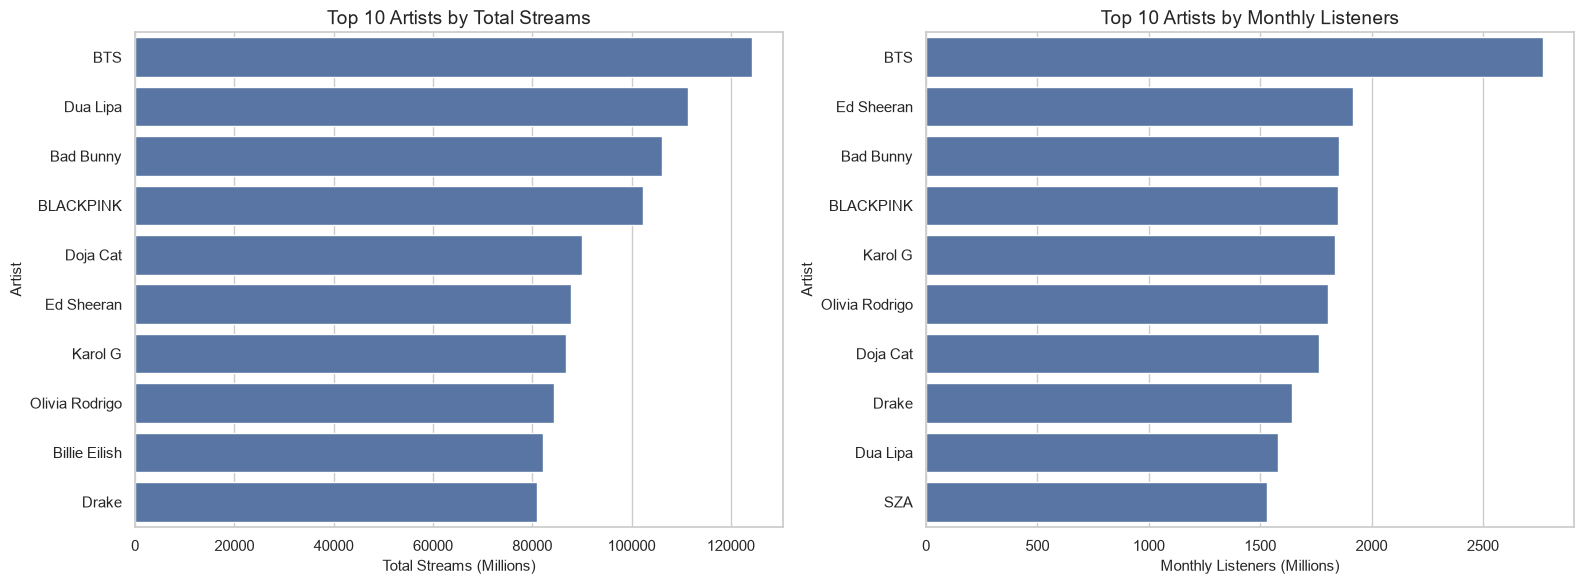

BUSINESS ANSWER — ARTIST REACH AND VOLUME:
- Highest streaming volume: BTS (124,299.47M streams).
- Largest monthly-listener base: BTS (2,770.65M listeners).


In [19]:
# ============================================================
# TOP ARTISTS BY STREAMS AND MONTHLY LISTENERS
# ============================================================

top_stream_artists = artist_summary.nlargest(10, "Total_Streams_M")
top_listener_artists = artist_summary.nlargest(10, "Monthly_Listeners_M")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top_stream_artists,
    x="Total_Streams_M",
    y="Artist",
    ax=axes[0]
)
axes[0].set_title("Top 10 Artists by Total Streams")
axes[0].set_xlabel("Total Streams (Millions)")
axes[0].set_ylabel("Artist")

sns.barplot(
    data=top_listener_artists,
    x="Monthly_Listeners_M",
    y="Artist",
    ax=axes[1]
)
axes[1].set_title("Top 10 Artists by Monthly Listeners")
axes[1].set_xlabel("Monthly Listeners (Millions)")
axes[1].set_ylabel("Artist")

plt.tight_layout()
plt.show()

if artist_summary.empty:
    print("Business Answer: No valid artist data available.")
else:
    top_artist = top_stream_artists.iloc[0]
    listener_artist = top_listener_artists.iloc[0]
    print(
        "BUSINESS ANSWER — ARTIST REACH AND VOLUME:\n"
        f"- Highest streaming volume: {top_artist['Artist']} "
        f"({top_artist['Total_Streams_M']:,.2f}M streams).\n"
        f"- Largest monthly-listener base: {listener_artist['Artist']} "
        f"({listener_artist['Monthly_Listeners_M']:,.2f}M listeners)."
    )


Top 10 artists by engagement score:


,Artist,Monthly_Listeners_M,Total_Hours_M,Engagement_Score,Avg_Skip_Rate
7,Dua Lipa,"1,578.33","389,040.16",246.49,22.48
3,Bad Bunny,"1,854.72","388,487.37",209.46,19.28
0,Ariana Grande,"1,352.66","269,727.49",199.41,22.43
1,BLACKPINK,"1,849.17","358,826.39",194.05,16.05
4,Billie Eilish,"1,469.91","274,053.85",186.44,21.93
13,Taylor Swift,"1,229.47","219,592.17",178.61,18.38
5,Doja Cat,"1,764.77","313,326.55",177.55,22.63
6,Drake,"1,643.83","285,927.94",173.94,21.24
9,Karol G,"1,836.16","305,313.18",166.28,21.81
10,Olivia Rodrigo,"1,805.98","298,871.80",165.49,18.99


Top 10 artists with the lowest average skip rates:


,Artist,Total_Streams_M,Avg_Duration_Min,Avg_Skip_Rate
1,BLACKPINK,"102,238.89",3.48,16.05
14,The Weeknd,"63,099.45",3.53,18.23
13,Taylor Swift,"61,295.49",3.45,18.38
12,SZA,"57,585.81",3.54,18.64
10,Olivia Rodrigo,"84,378.54",3.49,18.99
3,Bad Bunny,"106,216.16",3.53,19.28
11,Post Malone,"74,873.69",3.66,19.88
2,BTS,"124,299.47",3.65,21.14
6,Drake,"80,948.91",3.49,21.24
9,Karol G,"86,737.71",3.39,21.81


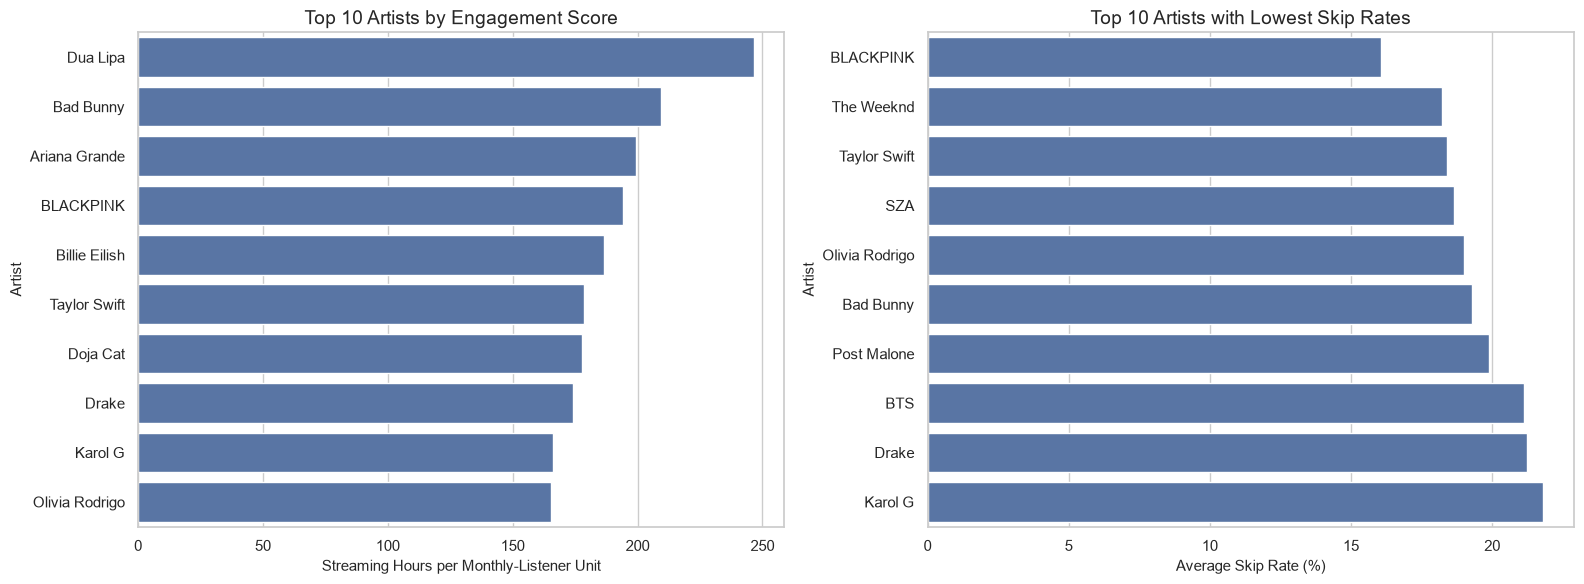

BUSINESS ANSWER — ARTIST ENGAGEMENT:
- Strongest engagement: Dua Lipa (score 246.49).
- Lowest average skip rate: BLACKPINK (16.05%).


In [20]:
# ============================================================
# ARTIST ENGAGEMENT AND SKIP-RATE PATTERNS
# ============================================================

engaged_artists = (
    artist_summary
    .dropna(subset=["Engagement_Score"])
    .sort_values("Engagement_Score", ascending=False)
)

lowest_skip_artists = (
    artist_summary
    .dropna(subset=["Avg_Skip_Rate"])
    .sort_values("Avg_Skip_Rate")
)

print("Top 10 artists by engagement score:")
display(
    engaged_artists[
        [
            "Artist",
            "Monthly_Listeners_M",
            "Total_Hours_M",
            "Engagement_Score",
            "Avg_Skip_Rate",
        ]
    ].head(10)
)

print("Top 10 artists with the lowest average skip rates:")
display(
    lowest_skip_artists[
        ["Artist", "Total_Streams_M", "Avg_Duration_Min", "Avg_Skip_Rate"]
    ].head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(
    data=engaged_artists.head(10),
    x="Engagement_Score",
    y="Artist",
    ax=axes[0]
)
axes[0].set_title("Top 10 Artists by Engagement Score")
axes[0].set_xlabel("Streaming Hours per Monthly-Listener Unit")
axes[0].set_ylabel("Artist")

sns.barplot(
    data=lowest_skip_artists.head(10),
    x="Avg_Skip_Rate",
    y="Artist",
    ax=axes[1]
)
axes[1].set_title("Top 10 Artists with Lowest Skip Rates")
axes[1].set_xlabel("Average Skip Rate (%)")
axes[1].set_ylabel("Artist")

plt.tight_layout()
plt.show()

if engaged_artists.empty:
    print("No valid artist engagement scores are available.")
else:
    strongest_artist = engaged_artists.iloc[0]
    best_skip_artist = lowest_skip_artists.iloc[0]
    print(
        "BUSINESS ANSWER — ARTIST ENGAGEMENT:\n"
        f"- Strongest engagement: {strongest_artist['Artist']} "
        f"(score {strongest_artist['Engagement_Score']:,.2f}).\n"
        f"- Lowest average skip rate: {best_skip_artist['Artist']} "
        f"({best_skip_artist['Avg_Skip_Rate']:.2f}%)."
    )


# 12. Genre Analysis

Genre performance is evaluated using listener reach, historical streams, recent streams, listening duration, streaming hours, and skip behavior.

In [21]:
# ============================================================
# 12. GENRE PERFORMANCE
# ============================================================

genre_summary = (
    clean_df
    .groupby("Genre", as_index=False)
    .agg(
        Monthly_Listeners_M=(
            "Monthly Listeners (Millions)",
            "sum"
        ),
        Total_Streams_M=(
            "Total Streams (Millions)",
            "sum"
        ),
        Total_Hours_M=(
            "Total Hours Streamed (Millions)",
            "sum"
        ),
        Recent_Streams_M=(
            "Streams Last 30 Days (Millions)",
            "sum"
        ),
        Avg_Duration_Min=(
            "Avg Stream Duration (Min)",
            "mean"
        ),
        Avg_Skip_Rate=(
            "Skip Rate (%)",
            "mean"
        )
    )
    .sort_values(
        "Total_Streams_M",
        ascending=False
    )
)

display(genre_summary)

,Genre,Monthly_Listeners_M,Total_Streams_M,Total_Hours_M,Recent_Streams_M,Avg_Duration_Min,Avg_Skip_Rate
0,Classical,"3,969.55","197,276.79","675,147.96","7,156.87",3.54,19.80
9,Rock,"3,169.93","148,418.93","514,864.25","5,904.98",3.53,21.14
3,Indie,"2,561.90","133,083.47","454,210.69","5,575.18",3.50,18.29
5,K-pop,"2,453.16","132,513.20","463,827.47","4,928.80",3.51,19.11
1,EDM,"2,592.99","125,801.69","453,184.72","4,003.01",3.52,20.79
6,Pop,"2,224.34","118,219.09","423,169.99","4,184.02",3.44,23.13
7,R&B,"2,055.10","113,951.78","399,807.28","3,866.28",3.62,19.89
2,Hip Hop,"2,190.64","111,958.51","382,786.41","5,147.45",3.53,21.70
8,Reggaeton,"2,032.86","105,789.80","367,315.38","5,017.87",3.56,20.10
4,Jazz,"2,270.14","103,563.78","342,870.29","3,739.79",3.43,20.00


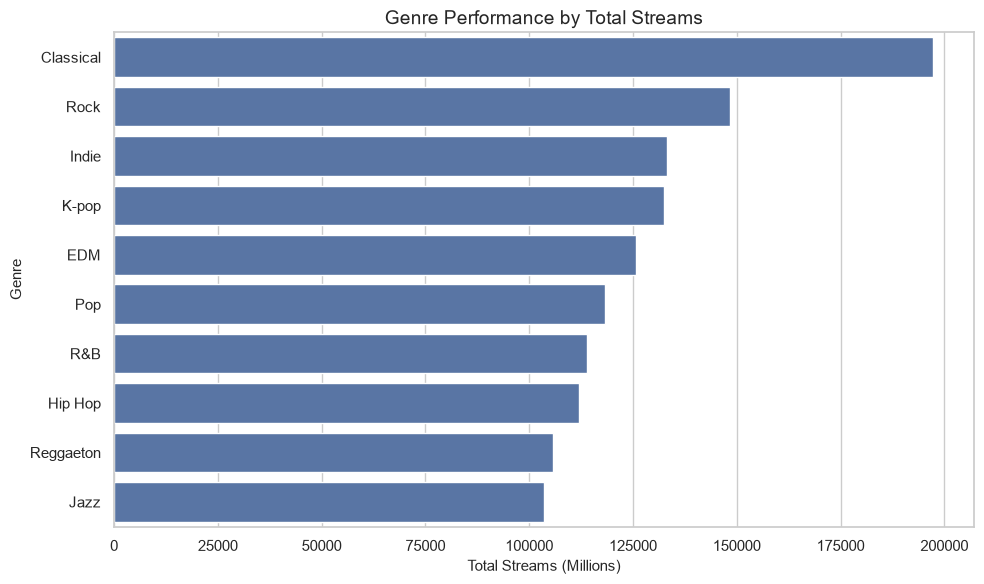

BUSINESS ANSWER — MOST POPULAR GENRE:
Classical has the highest overall streaming volume with 197,276.79 million streams.


In [22]:
# ============================================================
# GENRE POPULARITY
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=genre_summary,
    x="Total_Streams_M",
    y="Genre"
)

plt.title("Genre Performance by Total Streams")
plt.xlabel("Total Streams (Millions)")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

if genre_summary.empty:
    print("Business Answer: No valid genre data available.")

else:
    top_genre = genre_summary.iloc[0]

    print(
        f"BUSINESS ANSWER — MOST POPULAR GENRE:\n"
        f"{top_genre['Genre']} has the highest overall streaming volume "
        f"with {top_genre['Total_Streams_M']:,.2f} million streams."
    )

# 13. Genre Promotion Opportunity

The genre Spotify should promote is not automatically assumed to be the genre with the most historical streams.

A multi-metric opportunity score is created using:

- Total streams
- Recent 30-day streams
- Monthly listener reach
- Average stream duration
- Skip rate

High recent activity and engagement are rewarded, while high skip rates reduce the score.

In [23]:
# ============================================================
# 13. GENRE PROMOTION OPPORTUNITY
# ============================================================

promotion_df = genre_summary.copy()

score_columns = [
    "Total_Streams_M",
    "Recent_Streams_M",
    "Monthly_Listeners_M",
    "Avg_Duration_Min",
]

# Percentile ranks make differently scaled metrics comparable.
for column in score_columns:
    promotion_df[f"{column}_Score"] = (
        promotion_df[column]
        .rank(pct=True)
    )

# Lower skip rate is better.
promotion_df["Skip_Score"] = (
    promotion_df["Avg_Skip_Rate"]
    .rank(
        pct=True,
        ascending=False
    )
)

# Weighted business opportunity score.
promotion_df["Promotion_Score"] = (
    0.20 * promotion_df["Total_Streams_M_Score"]
    + 0.30 * promotion_df["Recent_Streams_M_Score"]
    + 0.20 * promotion_df["Monthly_Listeners_M_Score"]
    + 0.15 * promotion_df["Avg_Duration_Min_Score"]
    + 0.15 * promotion_df["Skip_Score"]
)

promotion_df = promotion_df.sort_values(
    "Promotion_Score",
    ascending=False
)

display(
    promotion_df[
        [
            "Genre",
            "Total_Streams_M",
            "Recent_Streams_M",
            "Monthly_Listeners_M",
            "Avg_Duration_Min",
            "Avg_Skip_Rate",
            "Promotion_Score"
        ]
    ]
)

,Genre,Total_Streams_M,Recent_Streams_M,Monthly_Listeners_M,Avg_Duration_Min,Avg_Skip_Rate,Promotion_Score
0,Classical,"197,276.79","7,156.87","3,969.55",3.54,19.80,0.94
9,Rock,"148,418.93","5,904.98","3,169.93",3.53,21.14,0.78
3,Indie,"133,083.47","5,575.18","2,561.90",3.50,18.29,0.74
5,K-pop,"132,513.20","4,928.80","2,453.16",3.51,19.11,0.60
1,EDM,"125,801.69","4,003.01","2,592.99",3.52,20.79,0.51
2,Hip Hop,"111,958.51","5,147.45","2,190.64",3.53,21.70,0.45
8,Reggaeton,"105,789.80","5,017.87","2,032.86",3.56,20.10,0.45
7,R&B,"113,951.78","3,866.28","2,055.10",3.62,19.89,0.43
6,Pop,"118,219.09","4,184.02","2,224.34",3.44,23.13,0.35
4,Jazz,"103,563.78","3,739.79","2,270.14",3.43,20.00,0.26


In [24]:
if promotion_df.empty:
    print("Business Answer: Promotion opportunity could not be calculated.")

else:
    promotion_genre = promotion_df.iloc[0]

    print(
        f"BUSINESS ANSWER — GENRE TO PROMOTE:\n"
        f"{promotion_genre['Genre']} has the strongest promotion opportunity "
        f"with a composite score of "
        f"{promotion_genre['Promotion_Score']:.3f}.\n\n"
        f"This recommendation considers recent streams, total streams, "
        f"listener reach, listening duration, and skip behavior rather "
        f"than relying only on historical popularity."
    )

BUSINESS ANSWER — GENRE TO PROMOTE:
Classical has the strongest promotion opportunity with a composite score of 0.940.

This recommendation considers recent streams, total streams, listener reach, listening duration, and skip behavior rather than relying only on historical popularity.


# 14. Album Analysis

Albums are ranked by total streams to identify high-performing releases.

In [25]:
# ============================================================
# 14. ALBUM PERFORMANCE
# ============================================================

album_summary = (
    clean_df
    .groupby(
        ["Artist", "Album"],
        as_index=False
    )
    .agg(
        Total_Streams_M=(
            "Total Streams (Millions)",
            "sum"
        ),
        Monthly_Listeners_M=(
            "Monthly Listeners (Millions)",
            "sum"
        ),
        Total_Hours_M=(
            "Total Hours Streamed (Millions)",
            "sum"
        ),
        Recent_Streams_M=(
            "Streams Last 30 Days (Millions)",
            "sum"
        ),
        Avg_Skip_Rate=(
            "Skip Rate (%)",
            "mean"
        )
    )
    .sort_values(
        "Total_Streams_M",
        ascending=False
    )
)

display(album_summary.head(10))

,Artist,Album,Total_Streams_M,Monthly_Listeners_M,Total_Hours_M,Recent_Streams_M,Avg_Skip_Rate
2,BTS,Proof,"124,299.47","2,770.65","437,253.81","4,419.42",21.14
7,Dua Lipa,Future Nostalgia,"111,305.99","1,578.33","389,040.16","4,422.26",22.48
3,Bad Bunny,Nadie Sabe Lo Que Va a Pasar Mañana,"106,216.16","1,854.72","388,487.37","3,975.80",19.28
1,BLACKPINK,BORN PINK,"102,238.89","1,849.17","358,826.39","3,200.08",16.05
5,Doja Cat,Scarlet,"90,098.83","1,764.77","313,326.55","3,343.57",22.63
8,Ed Sheeran,Autumn Variations,"87,859.35","1,915.77","303,690.13","3,384.25",21.87
9,Karol G,MAÑANA SERÁ BONITO,"86,737.71","1,836.16","305,313.18","3,398.55",21.81
10,Olivia Rodrigo,Guts,"84,378.54","1,805.98","298,871.80","3,538.79",18.99
4,Billie Eilish,Happier Than Ever,"82,174.91","1,469.91","274,053.85","3,188.44",21.93
6,Drake,For All The Dogs,"80,948.91","1,643.83","285,927.94","3,204.85",21.24


In [26]:
if album_summary.empty:
    print("Business Answer: No valid album data available.")

else:
    top_album = album_summary.iloc[0]

    print(
        f"BUSINESS ANSWER — HIGHEST-PERFORMING ALBUM:\n"
        f"'{top_album['Album']}' by {top_album['Artist']} generated "
        f"{top_album['Total_Streams_M']:,.2f} million total streams, "
        f"making it the highest-performing album in this dataset."
    )

BUSINESS ANSWER — HIGHEST-PERFORMING ALBUM:
'Proof' by BTS generated 124,299.47 million total streams, making it the highest-performing album in this dataset.


# 15. Free vs Premium Listening Behavior

Subscription groups are compared using:

- Listener reach
- Total streams
- Streaming hours
- Average listening duration
- Recent streams
- Skip rate

In [27]:
# ============================================================
# 15. FREE VS PREMIUM
# ============================================================

platform_summary = (
    clean_df
    .groupby("Platform Type", as_index=False)
    .agg(
        Records=("Platform Type", "size"),
        Monthly_Listeners_M=(
            "Monthly Listeners (Millions)",
            "sum"
        ),
        Total_Streams_M=(
            "Total Streams (Millions)",
            "sum"
        ),
        Total_Hours_M=(
            "Total Hours Streamed (Millions)",
            "sum"
        ),
        Recent_Streams_M=(
            "Streams Last 30 Days (Millions)",
            "sum"
        ),
        Avg_Duration_Min=(
            "Avg Stream Duration (Min)",
            "mean"
        ),
        Avg_Skip_Rate=(
            "Skip Rate (%)",
            "mean"
        )
    )
)

display(platform_summary)

,Platform Type,Records,Monthly_Listeners_M,Total_Streams_M,Total_Hours_M,Recent_Streams_M,Avg_Duration_Min,Avg_Skip_Rate
0,Free,250,"13,003.98","638,685.97","2,213,276.95","24,470.06",3.52,20.47
1,Premium,250,"12,516.63","651,891.07","2,263,907.49","25,054.19",3.52,20.27


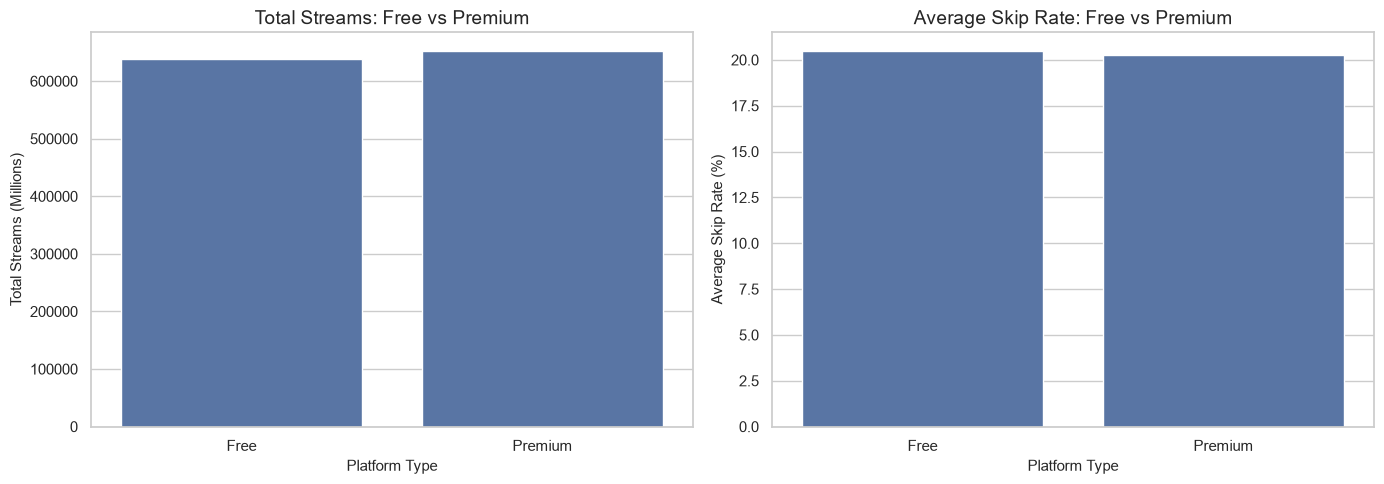

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=platform_summary,
    x="Platform Type",
    y="Total_Streams_M",
    ax=axes[0]
)
axes[0].set_title("Total Streams: Free vs Premium")
axes[0].set_xlabel("Platform Type")
axes[0].set_ylabel("Total Streams (Millions)")

sns.barplot(
    data=platform_summary,
    x="Platform Type",
    y="Avg_Skip_Rate",
    ax=axes[1]
)
axes[1].set_title("Average Skip Rate: Free vs Premium")
axes[1].set_xlabel("Platform Type")
axes[1].set_ylabel("Average Skip Rate (%)")

plt.tight_layout()
plt.show()


In [29]:
if platform_summary.empty:
    print("Business Answer: No valid platform data available.")
else:
    highest_stream_platform = platform_summary.nlargest(1, "Total_Streams_M").iloc[0]
    lowest_skip_platform = platform_summary.nsmallest(1, "Avg_Skip_Rate").iloc[0]
    free_duration = platform_summary.loc[
        platform_summary["Platform Type"].eq("Free"), "Avg_Duration_Min"
    ].iloc[0]
    premium_duration = platform_summary.loc[
        platform_summary["Platform Type"].eq("Premium"), "Avg_Duration_Min"
    ].iloc[0]
    duration_difference = abs(free_duration - premium_duration)

    print("BUSINESS ANSWER — FREE VS PREMIUM:")
    print(
        f"- Highest total streaming volume: "
        f"{highest_stream_platform['Platform Type']} "
        f"({highest_stream_platform['Total_Streams_M']:,.2f}M streams)"
    )
    print(
        f"- Lowest average skip rate: "
        f"{lowest_skip_platform['Platform Type']} "
        f"({lowest_skip_platform['Avg_Skip_Rate']:.2f}%)"
    )
    print(
        f"- Average duration: Free {free_duration:.3f} min; "
        f"Premium {premium_duration:.3f} min "
        f"(difference {duration_difference:.3f} min, effectively negligible)"
    )


BUSINESS ANSWER — FREE VS PREMIUM:
- Highest total streaming volume: Premium (651,891.07M streams)
- Lowest average skip rate: Premium (20.27%)
- Average duration: Free 3.521 min; Premium 3.521 min (difference 0.000 min, effectively negligible)


# 16. Listener Engagement and Skip-Rate Analysis

This section examines whether longer listening sessions are associated with lower or higher skipping behavior.

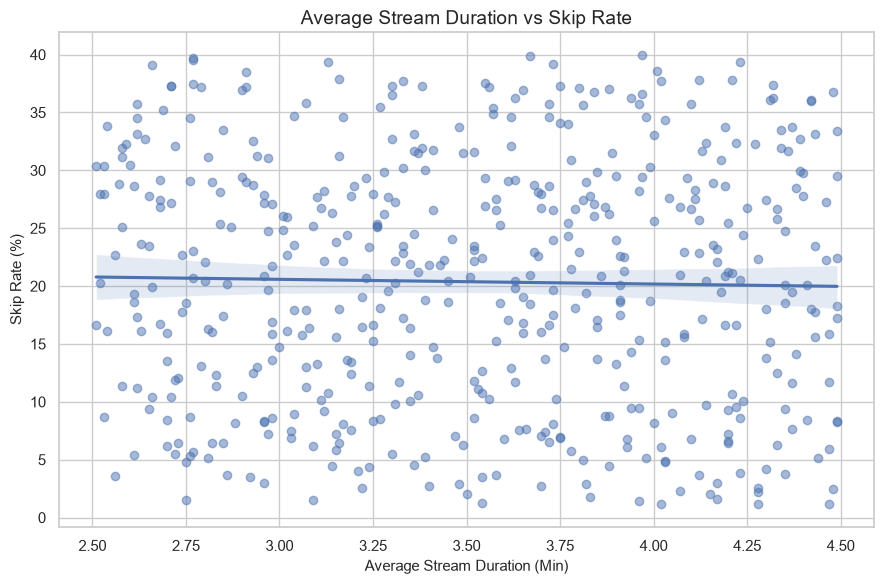

BUSINESS ANSWER — DURATION VS SKIP RATE:
Correlation = -0.022, indicating a negligible linear relationship.
Higher average stream duration is not meaningfully associated with lower skip rates in this dataset.


In [30]:
# ============================================================
# 16. ENGAGEMENT VS SKIP RATE
# ============================================================

duration_skip_df = clean_df[
    ["Avg Stream Duration (Min)", "Skip Rate (%)"]
].dropna()

if len(duration_skip_df) >= 2:
    duration_skip_corr = duration_skip_df[
        "Avg Stream Duration (Min)"
    ].corr(duration_skip_df["Skip Rate (%)"])

    plt.figure(figsize=(9, 6))
    sns.regplot(
        data=duration_skip_df,
        x="Avg Stream Duration (Min)",
        y="Skip Rate (%)",
        scatter_kws={"alpha": 0.5}
    )
    plt.title("Average Stream Duration vs Skip Rate")
    plt.xlabel("Average Stream Duration (Min)")
    plt.ylabel("Skip Rate (%)")
    plt.tight_layout()
    plt.show()

    if abs(duration_skip_corr) < 0.10:
        relationship = "a negligible linear relationship"
        business_interpretation = (
            "Higher average stream duration is not meaningfully associated "
            "with lower skip rates in this dataset."
        )
    elif duration_skip_corr < 0:
        relationship = "a negative linear relationship"
        business_interpretation = (
            "Higher average stream duration is associated with lower skip rates."
        )
    else:
        relationship = "a positive linear relationship"
        business_interpretation = (
            "Higher average stream duration is associated with higher skip rates."
        )

    print(
        "BUSINESS ANSWER — DURATION VS SKIP RATE:\n"
        f"Correlation = {duration_skip_corr:.3f}, indicating {relationship}.\n"
        f"{business_interpretation}"
    )
else:
    print(
        "Not enough valid observations to calculate "
        "the duration-skip correlation."
    )


,Genre,Avg_Skip_Rate,Avg_Duration_Min
3,Indie,18.29,3.50
5,K-pop,19.11,3.51
0,Classical,19.80,3.54
7,R&B,19.89,3.62
4,Jazz,20.00,3.43
8,Reggaeton,20.10,3.56
1,EDM,20.79,3.52
9,Rock,21.14,3.53
2,Hip Hop,21.70,3.53
6,Pop,23.13,3.44


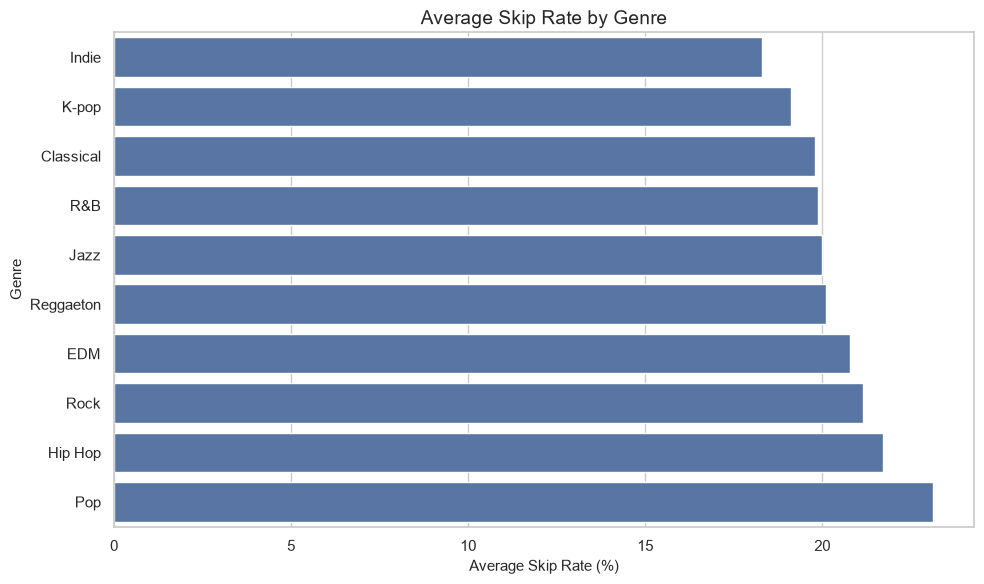

BUSINESS ANSWER — SKIP-RATE PATTERNS:
Indie has the lowest average skip rate at 18.29%, while Pop has the highest at 23.13%.


In [31]:
# ============================================================
# SKIP-RATE PATTERNS BY GENRE
# ============================================================

genre_skip = (
    clean_df
    .groupby("Genre", as_index=False)
    .agg(
        Avg_Skip_Rate=(
            "Skip Rate (%)",
            "mean"
        ),
        Avg_Duration_Min=(
            "Avg Stream Duration (Min)",
            "mean"
        )
    )
    .sort_values("Avg_Skip_Rate")
)

display(genre_skip)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=genre_skip,
    x="Avg_Skip_Rate",
    y="Genre"
)

plt.title("Average Skip Rate by Genre")
plt.xlabel("Average Skip Rate (%)")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

if not genre_skip.empty:
    
    lowest_skip_genre = genre_skip.iloc[0]
    highest_skip_genre = genre_skip.iloc[-1]

    print(
        f"BUSINESS ANSWER — SKIP-RATE PATTERNS:\n"
        f"{lowest_skip_genre['Genre']} has the lowest average skip rate "
        f"at {lowest_skip_genre['Avg_Skip_Rate']:.2f}%, while "
        f"{highest_skip_genre['Genre']} has the highest at "
        f"{highest_skip_genre['Avg_Skip_Rate']:.2f}%."
    )

# 17. Recent Streaming Performance

Recent performance uses Streams Last 30 Days to identify artists and genres currently generating strong listening activity.

,Artist,Recent_Streams_M,Total_Streams_M,Monthly_Listeners_M
7,Dua Lipa,"4,422.26","111,305.99","1,578.33"
2,BTS,"4,419.42","124,299.47","2,770.65"
3,Bad Bunny,"3,975.80","106,216.16","1,854.72"
10,Olivia Rodrigo,"3,538.79","84,378.54","1,805.98"
9,Karol G,"3,398.55","86,737.71","1,836.16"
8,Ed Sheeran,"3,384.25","87,859.35","1,915.77"
5,Doja Cat,"3,343.57","90,098.83","1,764.77"
12,SZA,"3,320.01","57,585.81","1,531.59"
6,Drake,"3,204.85","80,948.91","1,643.83"
1,BLACKPINK,"3,200.08","102,238.89","1,849.17"


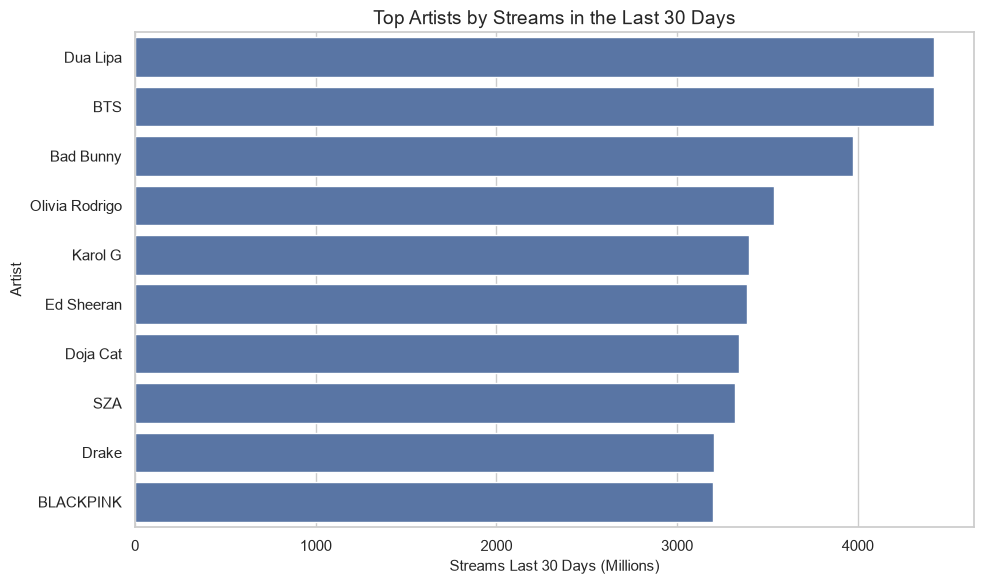

BUSINESS ANSWER — RECENT ARTIST PERFORMANCE:
Dua Lipa has the highest recent activity with 4,422.26 million streams during the last 30 days.


In [32]:
# ============================================================
# 17. RECENT STREAMING PERFORMANCE
# ============================================================

recent_artist_summary = (
    artist_summary
    .sort_values(
        "Recent_Streams_M",
        ascending=False
    )
)

display(
    recent_artist_summary[
        [
            "Artist",
            "Recent_Streams_M",
            "Total_Streams_M",
            "Monthly_Listeners_M"
        ]
    ].head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=recent_artist_summary.head(10),
    x="Recent_Streams_M",
    y="Artist"
)

plt.title("Top Artists by Streams in the Last 30 Days")
plt.xlabel("Streams Last 30 Days (Millions)")
plt.ylabel("Artist")

plt.tight_layout()
plt.show()

if not recent_artist_summary.empty:

    recent_top_artist = recent_artist_summary.iloc[0]

    print(
        f"BUSINESS ANSWER — RECENT ARTIST PERFORMANCE:\n"
        f"{recent_top_artist['Artist']} has the highest recent activity "
        f"with {recent_top_artist['Recent_Streams_M']:,.2f} million "
        f"streams during the last 30 days."
    )

In [33]:
recent_genre_summary = (
    genre_summary
    .sort_values(
        "Recent_Streams_M",
        ascending=False
    )
)

display(
    recent_genre_summary[
        [
            "Genre",
            "Recent_Streams_M",
            "Total_Streams_M"
        ]
    ]
)

if not recent_genre_summary.empty:

    recent_top_genre = recent_genre_summary.iloc[0]

    print(
        f"BUSINESS ANSWER — RECENT GENRE PERFORMANCE:\n"
        f"{recent_top_genre['Genre']} leads recent genre activity "
        f"with {recent_top_genre['Recent_Streams_M']:,.2f} million "
        f"streams during the last 30 days."
    )

,Genre,Recent_Streams_M,Total_Streams_M
0,Classical,"7,156.87","197,276.79"
9,Rock,"5,904.98","148,418.93"
3,Indie,"5,575.18","133,083.47"
2,Hip Hop,"5,147.45","111,958.51"
8,Reggaeton,"5,017.87","105,789.80"
5,K-pop,"4,928.80","132,513.20"
6,Pop,"4,184.02","118,219.09"
1,EDM,"4,003.01","125,801.69"
7,R&B,"3,866.28","113,951.78"
4,Jazz,"3,739.79","103,563.78"


BUSINESS ANSWER — RECENT GENRE PERFORMANCE:
Classical leads recent genre activity with 7,156.87 million streams during the last 30 days.


# 18. Release-Year Trends

Streaming totals are aggregated by release year to examine whether newer or older music dominates the dataset.

,Release Year,Total_Streams_M,Recent_Streams_M,Monthly_Listeners_M
0,2018,"191,826.13","7,165.21","3,832.61"
1,2019,"218,898.70","8,866.69","5,165.04"
2,2020,"208,336.53","9,603.78","4,281.44"
3,2021,"230,983.67","8,396.06","4,032.42"
4,2022,"245,756.44","8,888.09","4,293.20"
5,2023,"194,775.57","6,604.42","3,915.90"


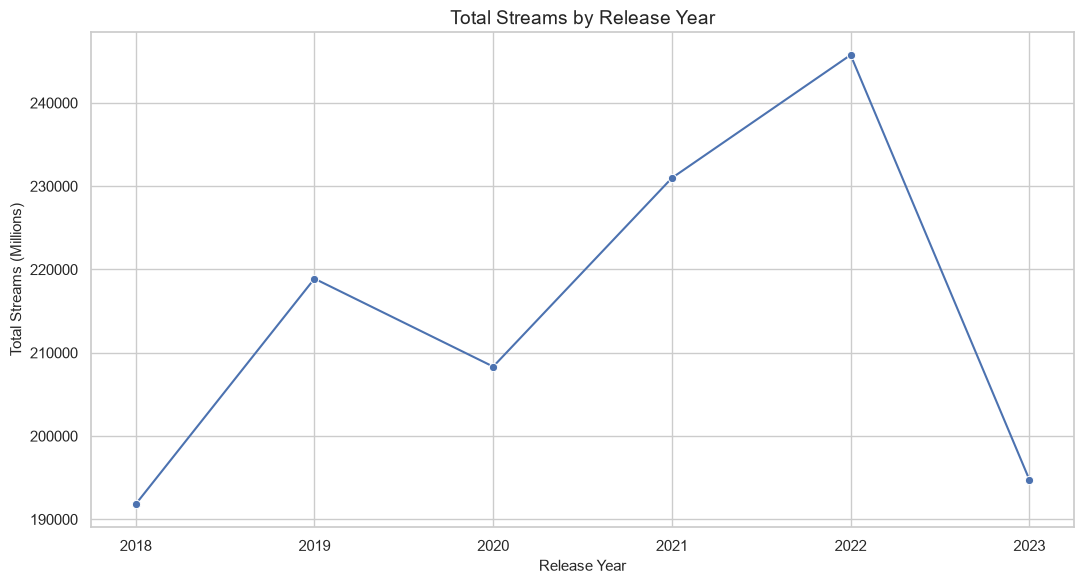

In [34]:
# ============================================================
# 18. RELEASE-YEAR TRENDS
# ============================================================

release_summary = (
    clean_df
    .dropna(subset=["Release Year"])
    .groupby("Release Year", as_index=False)
    .agg(
        Total_Streams_M=(
            "Total Streams (Millions)",
            "sum"
        ),
        Recent_Streams_M=(
            "Streams Last 30 Days (Millions)",
            "sum"
        ),
        Monthly_Listeners_M=(
            "Monthly Listeners (Millions)",
            "sum"
        )
    )
    .sort_values("Release Year")
)

display(release_summary.tail(15))

if not release_summary.empty:

    plt.figure(figsize=(11, 6))

    sns.lineplot(
        data=release_summary,
        x="Release Year",
        y="Total_Streams_M",
        marker="o"
    )

    plt.title("Total Streams by Release Year")
    plt.xlabel("Release Year")
    plt.ylabel("Total Streams (Millions)")

    plt.tight_layout()
    plt.show()

In [35]:
if release_summary.empty:
    print("Business Answer: Release-year analysis is unavailable.")

else:
    highest_stream_year = (
        release_summary
        .sort_values(
            "Total_Streams_M",
            ascending=False
        )
        .iloc[0]
    )

    highest_recent_year = (
        release_summary
        .sort_values(
            "Recent_Streams_M",
            ascending=False
        )
        .iloc[0]
    )

    print("BUSINESS ANSWER — RELEASE-YEAR TREND:")
    
    print(
        f"- Highest historical streaming year: "
        f"{int(highest_stream_year['Release Year'])} "
        f"({highest_stream_year['Total_Streams_M']:,.2f}M streams)"
    )
    
    print(
        f"- Highest recent streaming year: "
        f"{int(highest_recent_year['Release Year'])} "
        f"({highest_recent_year['Recent_Streams_M']:,.2f}M recent streams)"
    )

BUSINESS ANSWER — RELEASE-YEAR TREND:
- Highest historical streaming year: 2022 (245,756.44M streams)
- Highest recent streaming year: 2020 (9,603.78M recent streams)


# 19. Final Business Questions and Answers

This section converts the analysis into direct business answers.

In [36]:
# ============================================================
# 19. FINAL BUSINESS QUESTIONS AND ANSWERS
# ============================================================

print("=" * 75)
print("SPOTIFY LISTENER STATISTICS — FINAL BUSINESS ANSWERS")
print("=" * 75)

# 1. Most popular country
if not country_summary.empty:
    answer = country_summary.iloc[0]
    print(
        f"\n1. Most Popular Country:\n"
        f"   {answer['Country']} — "
        f"{answer['Total_Streams_M']:,.2f}M total streams."
    )

# 2. Most streamed artist
if not artist_summary.empty:
    answer = artist_summary.iloc[0]
    print(
        f"\n2. Most Streamed Artist:\n"
        f"   {answer['Artist']} — "
        f"{answer['Total_Streams_M']:,.2f}M total streams."
    )

# 3. Most popular genre
if not genre_summary.empty:
    answer = genre_summary.iloc[0]
    print(
        f"\n3. Most Popular Genre:\n"
        f"   {answer['Genre']} — "
        f"{answer['Total_Streams_M']:,.2f}M total streams."
    )

# 4. Genre promotion opportunity
if not promotion_df.empty:
    answer = promotion_df.iloc[0]
    print(
        f"\n4. Genre Spotify Should Consider Promoting:\n"
        f"   {answer['Genre']} — composite promotion score "
        f"{answer['Promotion_Score']:.3f}."
    )

# 5. Highest performing album
if not album_summary.empty:
    answer = album_summary.iloc[0]
    print(
        f"\n5. Highest-Performing Album:\n"
        f"   '{answer['Album']}' by {answer['Artist']} — "
        f"{answer['Total_Streams_M']:,.2f}M streams."
    )

# 6. Strongest artist engagement
if not engaged_artists.empty:
    answer = engaged_artists.iloc[0]
    print(
        f"\n6. Strongest Artist Engagement:\n"
        f"   {answer['Artist']} — engagement score "
        f"{answer['Engagement_Score']:.2f}."
    )

# 7. Subscription behavior
if not platform_summary.empty:

    stream_platform = (
        platform_summary
        .sort_values(
            "Total_Streams_M",
            ascending=False
        )
        .iloc[0]
    )

    low_skip_platform = (
        platform_summary
        .sort_values(
            "Avg_Skip_Rate"
        )
        .iloc[0]
    )

    print(
        f"\n7. Free vs Premium Behavior:\n"
        f"   Highest total streams: "
        f"{stream_platform['Platform Type']}.\n"
        f"   Lowest skip rate: "
        f"{low_skip_platform['Platform Type']}."
    )

# 8. Skip-rate relationship
if len(duration_skip_df) >= 2:
    print(
        f"\n8. Listening Duration vs Skip Rate:\n"
        f"   Correlation = {duration_skip_corr:.3f}."
    )

# 9. Recent artist performance
if not recent_artist_summary.empty:
    answer = recent_artist_summary.iloc[0]

    print(
        f"\n9. Strongest Recent Artist:\n"
        f"   {answer['Artist']} — "
        f"{answer['Recent_Streams_M']:,.2f}M streams in the last 30 days."
    )

# 10. Recent genre performance
if not recent_genre_summary.empty:
    answer = recent_genre_summary.iloc[0]

    print(
        f"\n10. Strongest Recent Genre:\n"
        f"    {answer['Genre']} — "
        f"{answer['Recent_Streams_M']:,.2f}M recent streams."
    )

# 11. Release-year trend
if not release_summary.empty:
    answer = release_summary.sort_values(
        "Total_Streams_M",
        ascending=False
    ).iloc[0]

    print(
        f"\n11. Highest-Streaming Release Year:\n"
        f"    {int(answer['Release Year'])} — "
        f"{answer['Total_Streams_M']:,.2f}M streams."
    )

print("\n" + "=" * 75)

SPOTIFY LISTENER STATISTICS — FINAL BUSINESS ANSWERS

1. Most Popular Country:
   Sweden — 93,449.76M total streams.

2. Most Streamed Artist:
   BTS — 124,299.47M total streams.

3. Most Popular Genre:
   Classical — 197,276.79M total streams.

4. Genre Spotify Should Consider Promoting:
   Classical — composite promotion score 0.940.

5. Highest-Performing Album:
   'Proof' by BTS — 124,299.47M streams.

6. Strongest Artist Engagement:
   Dua Lipa — engagement score 246.49.

7. Free vs Premium Behavior:
   Highest total streams: Premium.
   Lowest skip rate: Premium.

8. Listening Duration vs Skip Rate:
   Correlation = -0.022.

9. Strongest Recent Artist:
   Dua Lipa — 4,422.26M streams in the last 30 days.

10. Strongest Recent Genre:
    Classical — 7,156.87M recent streams.

11. Highest-Streaming Release Year:
    2022 — 245,756.44M streams.



# 20. Key Findings

The following cell automatically generates the principal findings from the cleaned dataset instead of hard-coding conclusions.

In [37]:
# ============================================================
# 20. KEY FINDINGS
# ============================================================

print("KEY FINDINGS\n")

if not country_summary.empty:
    print(
        f"• Regional demand is strongest in "
        f"{country_summary.iloc[0]['Country']} based on total streams."
    )

if not artist_summary.empty:
    print(
        f"• {artist_summary.iloc[0]['Artist']} is the highest-streamed "
        f"artist in the dataset."
    )

if not genre_summary.empty:
    print(
        f"• {genre_summary.iloc[0]['Genre']} leads historical genre "
        f"streaming performance."
    )

if not promotion_df.empty:
    print(
        f"• {promotion_df.iloc[0]['Genre']} has the strongest combined "
        f"promotion opportunity based on popularity, recent momentum, "
        f"reach, duration, and skip rate."
    )

if not engaged_artists.empty:
    print(
        f"• {engaged_artists.iloc[0]['Artist']} has the strongest "
        f"aggregated listener engagement."
    )

if not album_summary.empty:
    print(
        f"• '{album_summary.iloc[0]['Album']}' by "
        f"{album_summary.iloc[0]['Artist']} is the highest-performing album."
    )

if len(duration_skip_df) >= 2:
    print(
        f"• Average stream duration and skip rate have a correlation "
        f"of {duration_skip_corr:.3f}."
    )

if not recent_artist_summary.empty:
    print(
        f"• {recent_artist_summary.iloc[0]['Artist']} currently leads "
        f"30-day streaming activity."
    )

KEY FINDINGS

• Regional demand is strongest in Sweden based on total streams.
• BTS is the highest-streamed artist in the dataset.
• Classical leads historical genre streaming performance.
• Classical has the strongest combined promotion opportunity based on popularity, recent momentum, reach, duration, and skip rate.
• Dua Lipa has the strongest aggregated listener engagement.
• 'Proof' by BTS is the highest-performing album.
• Average stream duration and skip rate have a correlation of -0.022.
• Dua Lipa currently leads 30-day streaming activity.


# 21. Business Recommendations

Recommendations are based on the patterns identified in the exploratory analysis.

In [38]:
# ============================================================
# 21. BUSINESS RECOMMENDATIONS
# ============================================================

print("BUSINESS RECOMMENDATIONS\n")

if not country_summary.empty:
    print(
        f"1. Prioritize regional campaigns in "
        f"{country_summary.iloc[0]['Country']}, while comparing recent "
        f"growth in other markets before allocating the full marketing budget."
    )

if not recent_artist_summary.empty:
    print(
        f"2. Increase playlist placement and promotional support for "
        f"{recent_artist_summary.iloc[0]['Artist']} while recent streaming "
        f"momentum remains strong."
    )

if not promotion_df.empty:
    print(
        f"3. Consider additional promotion for "
        f"{promotion_df.iloc[0]['Genre']} because it performs strongly "
        f"across multiple popularity and engagement measures."
    )

if not engaged_artists.empty:
    print(
        f"4. Use highly engaged artists such as "
        f"{engaged_artists.iloc[0]['Artist']} for retention-focused playlists, "
        f"recommendations, and fan campaigns."
    )

if not genre_skip.empty:
    print(
        f"5. Investigate content discovery and playlist positioning for "
        f"{genre_skip.iloc[-1]['Genre']}, which has the highest average "
        f"skip rate."
    )

if not platform_summary.empty:

    best_skip = (
        platform_summary
        .sort_values("Avg_Skip_Rate")
        .iloc[0]
    )

    print(
        f"6. Study the listening experience of "
        f"{best_skip['Platform Type']} users because this group records "
        f"the lowest average skipping behavior."
    )

print(
    "7. Continue tracking Streams Last 30 Days separately from historical "
    "streams so current momentum is not hidden by older catalog success."
)

BUSINESS RECOMMENDATIONS

1. Prioritize regional campaigns in Sweden, while comparing recent growth in other markets before allocating the full marketing budget.
2. Increase playlist placement and promotional support for Dua Lipa while recent streaming momentum remains strong.
3. Consider additional promotion for Classical because it performs strongly across multiple popularity and engagement measures.
4. Use highly engaged artists such as Dua Lipa for retention-focused playlists, recommendations, and fan campaigns.
5. Investigate content discovery and playlist positioning for Pop, which has the highest average skip rate.
6. Study the listening experience of Premium users because this group records the lowest average skipping behavior.
7. Continue tracking Streams Last 30 Days separately from historical streams so current momentum is not hidden by older catalog success.


# 22. Conclusion

This exploratory data analysis examined Spotify listening behavior across countries, artists, genres, albums, release years, and platform types.

The analysis combined historical popularity with recent streaming activity, listener reach, listening duration, streaming hours, and skip behavior. This provides a broader view of performance than relying on total streams alone.

The notebook identifies:

- Leading countries
- Top artists
- High-performing genres and albums
- Strong listener-engagement artists
- Free vs Premium behavioral differences
- Skip-rate patterns
- Recent streaming leaders
- Release-year trends
- Data-driven genre promotion opportunities

No machine-learning model was required. All conclusions are derived directly from descriptive statistics, aggregation, visualization, and exploratory analysis using Python, Pandas, NumPy, Matplotlib, and Seaborn.